# Nudging Method for 1D Car Position Estimation

This notebook demonstrates a basic implementation of the **Nudging** method to estimate the position of a car moving at constant velocity, using noisy position observations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time settings
dt = 0.1
T = 10
steps = int(T/dt)
time = np.linspace(0, T, steps)

# True velocity and initial position
v_true = 1.5
x0 = 0.0

# True position
x_true = x0 + v_true * time

# Observations (noisy position)
noise_std = 2.0
y_obs = x_true + np.random.normal(0, noise_std, size=steps)

In [2]:
# Nudging settings
alpha = 0.3  # nudging strength
x_nudge = np.zeros(steps)
x_nudge[0] = 0.0  # initial guess

# Apply nudging
for k in range(1, steps):
    dxdt = v_true + alpha * (y_obs[k-1] - x_nudge[k-1])
    x_nudge[k] = x_nudge[k-1] + dt * dxdt

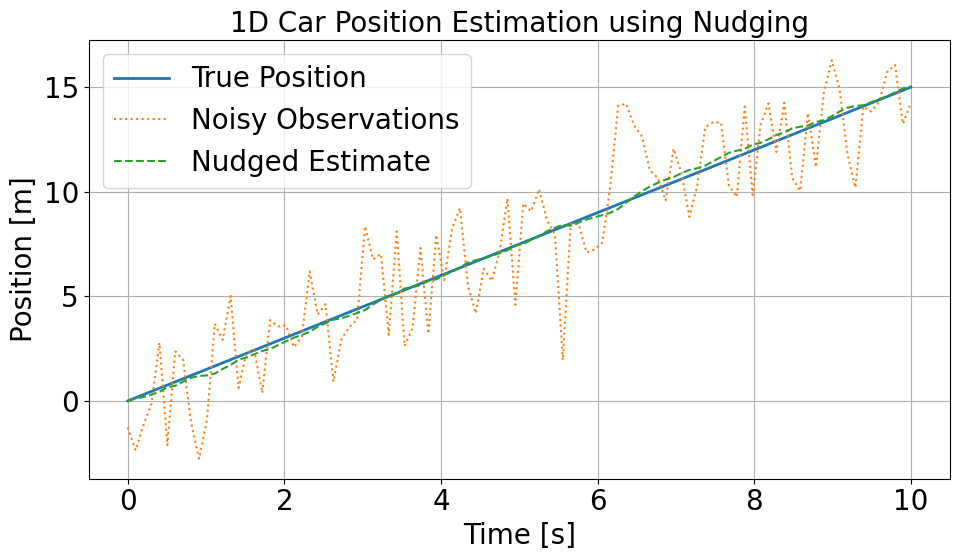

In [5]:
import matplotlib.pyplot as plt

# Cambiar fuentes globalmente (opcional)
plt.rcParams.update({
    'font.size': 20,            # tamaño base
    'axes.titlesize': 20,       # título de la figura
    'axes.labelsize': 20,       # etiquetas de ejes
    'xtick.labelsize': 20,      # ticks del eje x
    'ytick.labelsize': 20,      # ticks del eje y
    'legend.fontsize': 20,      # leyenda
    'figure.titlesize': 20      # título general de figura
})

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(time, x_true, label='True Position', linewidth=2)
plt.plot(time, y_obs, label='Noisy Observations', linestyle='dotted')
plt.plot(time, x_nudge, label='Nudged Estimate', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Position [m]')
plt.title('1D Car Position Estimation using Nudging')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation:
- The nudging method pulls the model state toward the noisy measurements.
- Parameter `alpha` controls how fast the correction happens.
- This example shows how nudging can stabilize the model and follow observations.